In [1]:
import torch
import torch.nn as nn
import matplotlib.pyplot as plt
import numpy as np
from typing import Callable, Optional
import sys
import os

# This (hopefully) sets the root directory for anyone using the repo
cwd = os.getcwd()  # poison-perf/poisoning/
root = os.path.dirname(cwd)  # poison-perf/
sys.path.append(root)

from utils.algorithms import RGD, RGD_audit, PerfGD
from utils.experiment_setup import setup_1d_non_linear_experiment, setup_binary_classification, setup_non_convex_1d
# from poisoning.oracle import oracle_poison_function, RGD_update_estimator, PerfGD_update_estimator, classification_sampling_estimator, gaussian_sampling_estimator
from poisoning.black_box_poison import black_box_poison_naive, black_box_poison_orthogonal, black_box_poison_classification
from utils.plotting import plot_results_1d, plot_results_2d

# Nonlinear Mean

In [2]:
a0 = 1.0
a1 = 1.0

proj_theta = lambda theta: torch.clamp(theta, min=-1.0, max=1.0)
mu, sigma, D_theta, loss, theta_0, grad2_est, f_hat, info = setup_1d_non_linear_experiment(a0=a0, a1=a1, perfGD=True)

## RGD + Naive Mean Shift

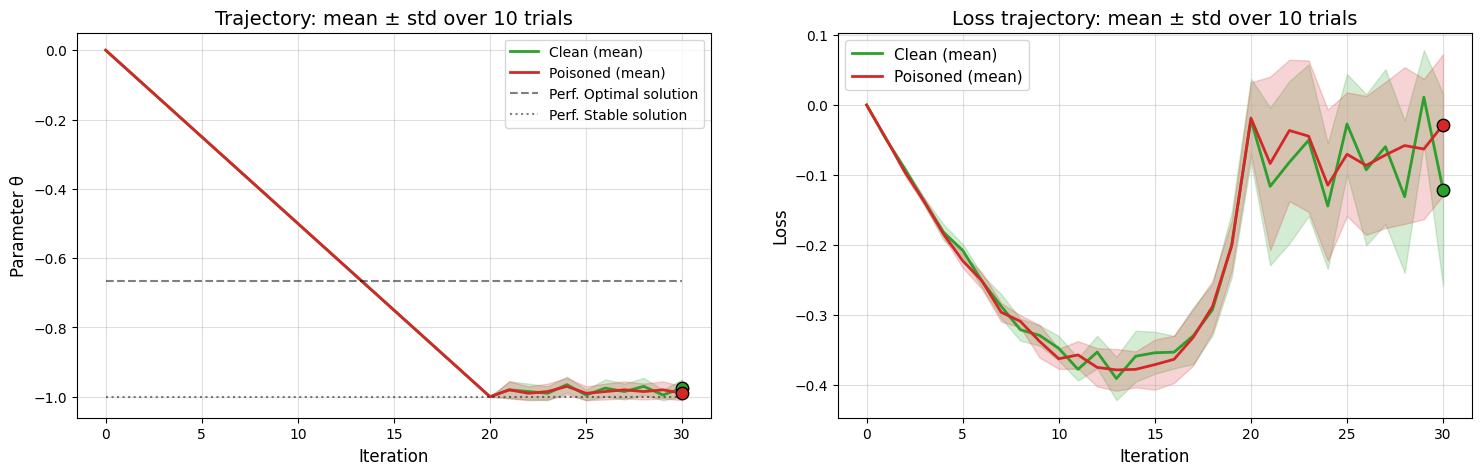

In [3]:
black_box_poison_function = black_box_poison_naive

n_trials = 10

n = 500
eta = 0.05
max_iter = 30

epsilon = 0.5
delta = 1.0

def run_trial():
    _, all_theta_clean, all_losses_clean = RGD(
                D_theta=D_theta,
                loss=loss,
                theta_0=theta_0.clone(),
                n=n,
                eta=eta,
                max_iter=max_iter,
                proj_theta=proj_theta,
                return_losses=True
    )

    _, all_theta_poisoned, all_losses_poisoned = RGD(
                D_theta=D_theta,
                loss=loss,
                theta_0=theta_0.clone(),
                n=n,
                eta=eta,
                max_iter=max_iter,
                proj_theta=proj_theta,
                return_losses=True,
                poison_function=black_box_poison_function,
                epsilon=epsilon,
                delta=delta,
            )

    return all_theta_clean, all_theta_poisoned, all_losses_clean, all_losses_poisoned

all_theta_clean_list = []
all_theta_poisoned_list = []
all_loss_clean_list = []
all_loss_poisoned_list = []

for trial in range(n_trials):
    all_theta_clean, all_theta_poisoned, all_loss_clean, all_loss_poisoned = run_trial()
    all_theta_clean_list.append(all_theta_clean) 
    all_theta_poisoned_list.append(all_theta_poisoned)
    all_loss_clean_list.append(all_loss_clean)
    all_loss_poisoned_list.append(all_loss_poisoned)

fig, (ax1, ax2) = plot_results_1d(all_theta_clean_list, 
                    all_theta_poisoned_list,
                    all_loss_clean_list, 
                    all_loss_poisoned_list
                    )

ax1.hlines(info['theta_optimal'], xmin=0, xmax=30, color='black', linestyle='--', label='Perf. Optimal solution', alpha=0.5)
ax1.hlines(info['theta_stable'], xmin=0, xmax=30, color='black', linestyle=':', label='Perf. Stable solution', alpha=0.5)
ax1.legend()

plt.show()

### Plot loss and theta gap as a function of delta

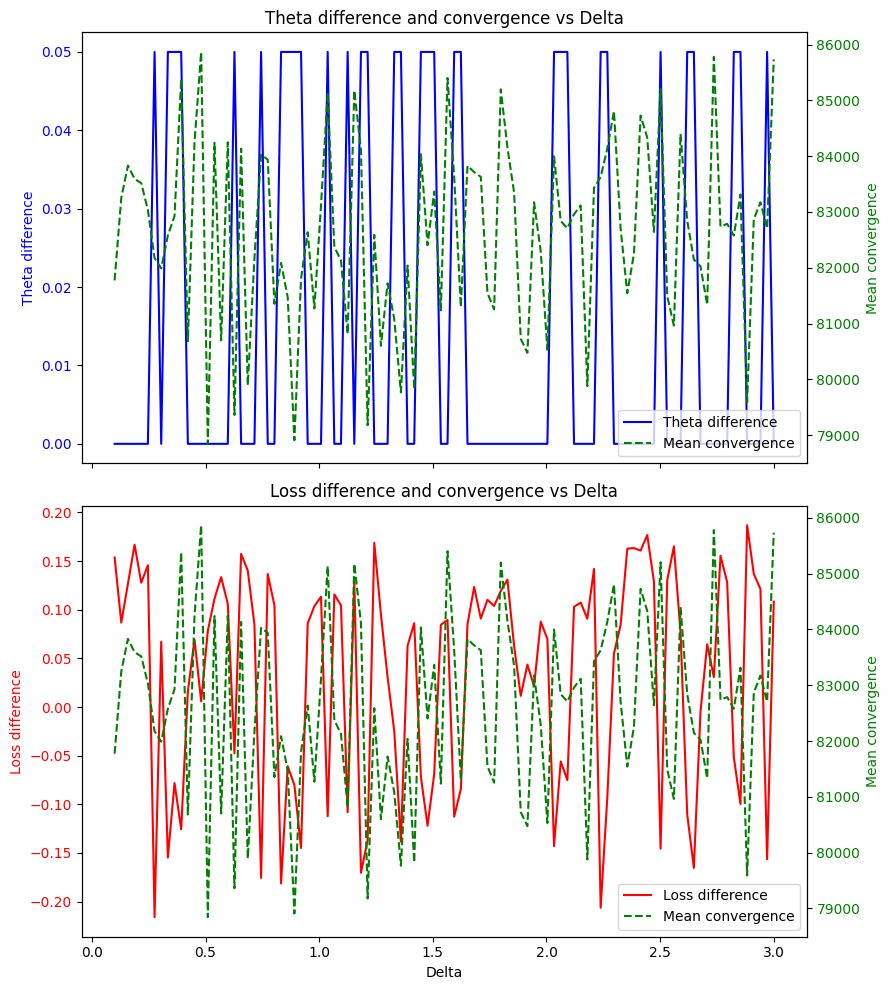

In [4]:
delta_vals = np.linspace(0.1, 3.0, 100)
black_box_poison_function = black_box_poison_naive
epsilon = 0.5

theta_clean, _, all_losses_clean = RGD(
                D_theta=D_theta,
                loss=loss,
                theta_0=theta_0.clone(),
                proj_theta=proj_theta,
                n=n,
                eta=eta,
                max_iter=max_iter,
                return_losses=True
    )

theta_clean = theta_clean.item()
loss_clean = all_losses_clean[-1]

losses_poisoned, theta_poisoned, mean_convergence = [], [], []
for delta in delta_vals:
    _theta_poisoned, _, all_losses_poisoned, convergence_metrics = RGD_audit(
                D_theta=D_theta,
                loss=loss,
                theta_0=theta_0.clone(),
                proj_theta=proj_theta,
                n=n,
                eta=eta,
                max_iter=max_iter,
                epsilon=epsilon,
                delta=delta,
    )

    losses_poisoned.append(all_losses_poisoned[-1])
    theta_poisoned.append(_theta_poisoned.item())
    mean_convergence.append(np.mean(convergence_metrics))

losses_poisoned = np.array(losses_poisoned)
theta_poisoned = np.array(theta_poisoned)
mean_convergence = np.array(mean_convergence)

# Create two subplots: top = theta gap, bottom = loss gap
fig, (ax_theta, ax_loss) = plt.subplots(2, 1, figsize=(9, 10), sharex=True)

# Theta subplot (left axis: theta gap, right axis: convergence)
ln_theta = ax_theta.plot(delta_vals, theta_poisoned - theta_clean, color='blue', label='Theta difference')
ax_theta.set_ylabel('Theta difference', color='blue')
ax_theta.tick_params(axis='y', labelcolor='blue')
ax_theta.set_title('Theta difference and convergence vs Delta')
ax_theta_right = ax_theta.twinx()
ln_conv_theta = ax_theta_right.plot(delta_vals, mean_convergence, color='green', linestyle='--', label='Mean convergence')
ax_theta_right.set_ylabel('Mean convergence', color='green')
ax_theta_right.tick_params(axis='y', labelcolor='green')
# Combined legend for theta subplot
lines = ln_theta + ln_conv_theta
labels = [l.get_label() for l in lines]
ax_theta.legend(lines, labels, loc='lower right')

# Loss subplot (left axis: loss gap, right axis: convergence)
ln_loss = ax_loss.plot(delta_vals, losses_poisoned - loss_clean, color='red', label='Loss difference')
ax_loss.set_xlabel('Delta')
ax_loss.set_ylabel('Loss difference', color='red')
ax_loss.tick_params(axis='y', labelcolor='red')
ax_loss.set_title('Loss difference and convergence vs Delta')
ax_loss_right = ax_loss.twinx()
ln_conv_loss = ax_loss_right.plot(delta_vals, mean_convergence, color='green', linestyle='--', label='Mean convergence')
ax_loss_right.set_ylabel('Mean convergence', color='green')
ax_loss_right.tick_params(axis='y', labelcolor='green')
# Combined legend for loss subplot
lines = ln_loss + ln_conv_loss
labels = [l.get_label() for l in lines]
ax_loss.legend(lines, labels, loc='lower right')

plt.tight_layout()
plt.show()

### Save Results

In [5]:
import pickle
pickle.dump({
    "delta_vals": delta_vals, 
    "theta_diff": theta_poisoned - theta_clean, 
    "loss_diff": losses_poisoned - loss_clean
}, open("black_box_poison_rgd_delta_sweep.pkl", "wb"))

## PerfGD + Naive Mean Shift

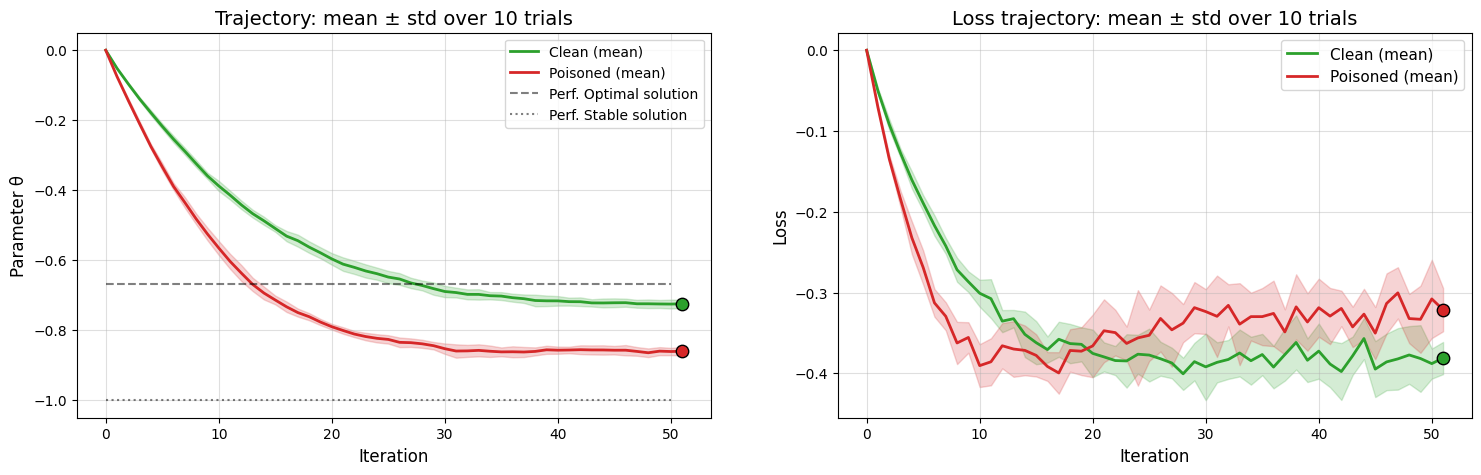

In [6]:
black_box_poison_function = black_box_poison_naive

n_trials = 10

n = 500
eta = 0.05
max_iter = 50

epsilon = 0.5
delta = 1.0

def run_trial():
    _, all_theta_clean, all_losses_clean = PerfGD(
                f_hat=f_hat,
                grad2_est=grad2_est,
                D_theta=D_theta,
                loss=loss,
                theta_0=theta_0.clone(),
                proj_theta=proj_theta,
                n=n,
                eta=eta,
                max_iter=max_iter,
                return_losses=True  
    )

    _, all_theta_poisoned, all_losses_poisoned = PerfGD(
                f_hat=f_hat,
                grad2_est=grad2_est,
                D_theta=D_theta,
                loss=loss,
                theta_0=theta_0.clone(),
                proj_theta=proj_theta,
                n=n,
                eta=eta,
                max_iter=max_iter,
                return_losses=True,
                poison_function=black_box_poison_function,
                epsilon=epsilon,
                delta=delta,
    )

    return all_theta_clean, all_theta_poisoned, all_losses_clean, all_losses_poisoned

all_theta_clean_list = []
all_theta_poisoned_list = []
all_loss_clean_list = []
all_loss_poisoned_list = []

for trial in range(n_trials):
    all_theta_clean, all_theta_poisoned, all_loss_clean, all_loss_poisoned = run_trial()
    all_theta_clean_list.append(all_theta_clean) 
    all_theta_poisoned_list.append(all_theta_poisoned)
    all_loss_clean_list.append(all_loss_clean)
    all_loss_poisoned_list.append(all_loss_poisoned)

fig, (ax1, ax2) = plot_results_1d(all_theta_clean_list, 
                    all_theta_poisoned_list,
                    all_loss_clean_list, 
                    all_loss_poisoned_list
                    )

ax1.hlines(info['theta_optimal'], xmin=0, xmax=50, color='black', linestyle='--', label='Perf. Optimal solution', alpha=0.5)
ax1.hlines(info['theta_stable'], xmin=0, xmax=50, color='black', linestyle=':', label='Perf. Stable solution', alpha=0.5)
ax1.legend()

plt.show()

### PerfGD: Plot loss and theta gap as a function of delta

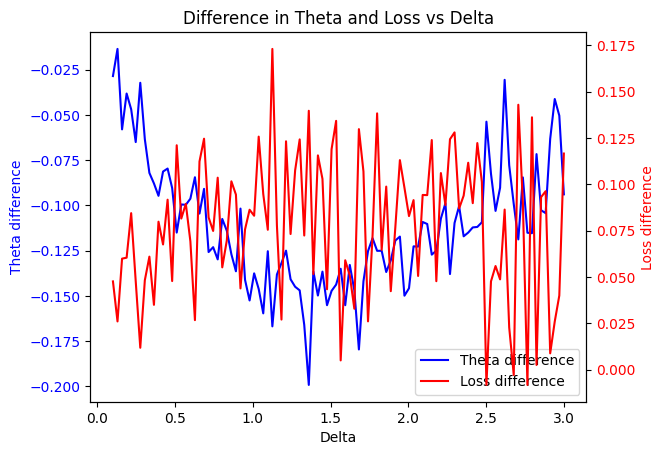

In [7]:
delta_vals = np.linspace(0.1, 3.0, 100)
black_box_poison_function = black_box_poison_naive
epsilon = 0.5

theta_clean, _, all_losses_clean = PerfGD(
                f_hat=f_hat,
                grad2_est=grad2_est,
                D_theta=D_theta,
                loss=loss,
                theta_0=theta_0.clone(),
                proj_theta=proj_theta,
                n=n,
                eta=eta,
                max_iter=max_iter,
                return_losses=True  
    )

theta_clean = theta_clean.item()
loss_clean = all_losses_clean[-1]

losses_poisoned, theta_poisoned = [], []
for delta in delta_vals:
    _theta_poisoned, _, all_losses_poisoned = PerfGD(
                f_hat=f_hat,
                grad2_est=grad2_est,
                D_theta=D_theta,
                loss=loss,
                theta_0=theta_0.clone(),
                proj_theta=proj_theta,
                n=n,
                eta=eta,
                max_iter=max_iter,
                return_losses=True,
                poison_function=black_box_poison_function,
                epsilon=epsilon,
                delta=delta,
    )

    losses_poisoned.append(all_losses_poisoned[-1])
    theta_poisoned.append(_theta_poisoned.item())

losses_poisoned = np.array(losses_poisoned)
theta_poisoned = np.array(theta_poisoned)

fig, ax_left = plt.subplots()
# Left axis: theta difference
ln1 = ax_left.plot(delta_vals, theta_poisoned - theta_clean, color='blue', label='Theta difference')
ax_left.set_xlabel('Delta')
ax_left.set_ylabel('Theta difference', 
                   color='blue')
ax_left.tick_params(axis='y', labelcolor='blue')

# Right axis: loss difference
ax_right = ax_left.twinx()
ln2 = ax_right.plot(delta_vals, losses_poisoned - loss_clean, color='red', label='Loss difference')
ax_right.set_ylabel('Loss difference', color='red')
ax_right.tick_params(axis='y', labelcolor='red')

# Combined legend
lines = ln1 + ln2
labels = [l.get_label() for l in lines]
ax_left.legend(lines, labels, loc='lower right')

ax_left.set_title('Difference in Theta and Loss vs Delta')
plt.show()

In [8]:
import pickle
pickle.dump({
    "delta_vals": delta_vals, 
    "theta_diff": theta_poisoned - theta_clean, 
    "loss_diff": losses_poisoned - loss_clean
}, open("black_box_poison_perfgd_delta_sweep.pkl", "wb"))


# 2D Example

## RGD + Orthogonal Mean Shift

## PerfGD + Orthogonal Mean Shift

### Some kind of comparison for naive vs orthogonal?

# Binary Classification